# Test

In [9]:
# import module
import gwosc
from gwosc.datasets import event_gps, find_datasets
from gwpy.timeseries import TimeSeries
import gwpy
from pycbc.waveform import get_td_waveform
import pylab
from matplotlib import pyplot as plt
from gwpy.plot import Plot
from gwpy.signal import filter_design
import numpy as np
from gwosc.api import fetch_event_json
import h5py
from pycbc import inference

In [10]:
# Event name
name_event = 'GW170817'

# Get the GPS time for the event
gps = event_gps(name_event)

# segment of time to get around the GPS time
segment = (int(gps)-4, int(gps)+4)


In [11]:
# Find all datasets associated with the event name
datasets = find_datasets(type='event', detector=None, segment=segment)

# Find the newest dataset
if datasets:
    datasets.sort(reverse=True)  # Sort by string, to get newest first

    # Get the newest version of the event
    newest_event_name = datasets[0]

    # Get event parameters
    event_data = fetch_event_json(newest_event_name)

    # Extract distance and uncertainties from the event data
    distance = event_data['events'][newest_event_name].get('luminosity_distance')
    distance_lower = event_data['events'][newest_event_name].get('luminosity_distance_lower')
    distance_upper = event_data['events'][newest_event_name].get('luminosity_distance_upper')
    
    # Extract masses and uncertainties from event data
    mass1 = event_data['events'][newest_event_name].get('mass_1_source')
    mass1_lower = event_data['events'][newest_event_name].get('mass_1_source_lower')
    mass1_upper = event_data['events'][newest_event_name].get('mass_1_source_upper')
    
    mass2 = event_data['events'][newest_event_name].get('mass_2_source')
    mass2_lower = event_data['events'][newest_event_name].get('mass_2_source_lower')
    mass2_upper = event_data['events'][newest_event_name].get('mass_2_source_upper')

    if distance is not None:
        print(f"Distance to {newest_event_name}: {distance} Mpc")
        print(f"Uncertainty: {distance_lower} Mpc, +{distance_upper} Mpc")
        print('')
    else:
        print(f"No distance data available for {newest_event_name}")
        print('')
        
    if mass1 is not None:
        print(f"mass 1 of {newest_event_name}: {mass1} M_Sun")
        print(f"Uncertainty: {mass1_lower} M_Sun, +{mass1_upper} M_Sun")
        print('')
    else:
        print(f"No mass 1 data available for {newest_event_name}")
        print('')
        
    if mass2 is not None:
        print(f"mass 2 of {newest_event_name}: {mass2} M_Sun")
        print(f"Uncertainty: {mass2_lower} M_Sun, +{mass2_upper} M_Sun")
        print('')
    else:
        print(f"No mass 2 data available for {newest_event_name}")
        print('')
else:
    print(f"Could not find a dataset for event: {name_event}")


Distance to GW170817-v3: 40.0 Mpc
Uncertainty: -15.0 Mpc, +7.0 Mpc

mass 1 of GW170817-v3: 1.46 M_Sun
Uncertainty: -0.1 M_Sun, +0.12 M_Sun

mass 2 of GW170817-v3: 1.27 M_Sun
Uncertainty: -0.09 M_Sun, +0.09 M_Sun



In [12]:
# get a list of all the available parameters and urls for this event
strain_data = event_data['events'][newest_event_name].get('strain')
# List of detectors
detectors = ['G1', 'V1', 'H1', 'L1']

# Filter URLs for sampling rate 4096 and duration 32
filtered_urls = []
for file_info in strain_data:
    if file_info['sampling_rate'] == 4096 and file_info['duration'] == 32 and file_info['format'] == 'gwf':
        if any(detector in file_info['detector'] for detector in detectors):
            filtered_urls.append(file_info['url'])

In [13]:
# assign available urls to data
gdata = hdata = ldata = vdata = None
for url in filtered_urls:
    if "G-G1" in url:
        gdata = url
    elif "H-H1" in url:
        hdata = url
    elif "L-L1" in url:
        ldata = url
    elif "V-V1" in url:
        vdata = url

In [14]:
from pycbc.catalog import Merger
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.frame import read_frame
from pycbc.filter import highpass, resample_to_delta_t
from astropy.utils.data import download_file

low_freq = 15

url_map = {'V1': vdata, 'G1': gdata, 'H1': hdata, 'L1': ldata}

# Initialize dictionaries for storing data
data_filenames = {}
psds = {}
data = {}

# Loop through each detector to get url
for detector in detectors:
    print(f"Processing {detector} data")
    
    # Get the URL for available detector
    url = url_map.get(detector)
    
    # Check if URL is None
    if url is None:
        print(f"No URL available for {detector}")
        continue

    # Download the file
    fname = download_file(url, cache=True)
    data_filenames[detector] = fname

    # Load the time series data for 4 seconds before and after the event
    ts = read_frame(fname, f"{detector}:GWOSC-4KHZ_R1_STRAIN",
                    start_time=int(gps - 4),
                    end_time=int(gps + 4))
    
    # Preprocess the data: high-pass filter, resample, and convert to frequency series
    ts = highpass(ts, low_freq)                       # Remove low-frequency content
    ts = resample_to_delta_t(ts, 1.0 / 2048)          # Resample to 2048 Hz
    data[detector] = ts.to_frequencyseries()          # Convert to frequency series
    
    # Estimate and process the power spectral density (PSD)
    psd = interpolate(ts.psd(4), ts.delta_f)
    psd = inverse_spectrum_truncation(psd, int(4 * psd.sample_rate), 
                                      trunc_method='hann', 
                                      low_frequency_cutoff=low_freq)
    psds[detector] = psd

Processing G1 data
Processing V1 data
Processing H1 data
Processing L1 data


In [15]:
from pycbc.inference import models, sampler
from pycbc.distributions import Uniform, JointDistribution, SinAngle
import numpy

approximant = 'IMRPhenomXPHM'

# known parameters
static = {'mass1':mass1,
          'mass2':mass2,
          'f_lower':low_freq,
          'approximant':approximant,
          'polarization':0
         }

# variable that we want to find
variable = ('ra', 'dec', 'distance',
            'inclination',
            'tc')

# Guesses of the variable
inclination_prior = SinAngle(inclination=None)
distance_prior = Uniform(distance=(distance + distance_lower, distance + distance_upper))
tc_prior = Uniform(tc=(gps-1, gps+1))
ra_prior = Uniform(ra=(0, 2 * numpy.pi))
dec_prior = Uniform(dec=(-numpy.pi / 2, numpy.pi / 2))

prior = JointDistribution(
    variable, inclination_prior, distance_prior, tc_prior, ra_prior, dec_prior)

In [16]:
import copy
from pycbc.inference.sampler import emcee_pt
# create the model
model = models.SingleTemplate(variable, copy.deepcopy(data),
                              low_frequency_cutoff={'H1':low_freq, 'L1':low_freq, 'V1':low_freq, 'G1':low_freq},
                              psds = psds,
                              static_params = static,
                              prior = prior,
                              sample_rate = 2048,
                              )
# parameters of this function are:
# model
# number of temeratures  
# number of walker
# number of paralleliztion
ntemps = 5
nwalkers = 300
nprocesses = 8
smpl = emcee_pt.EmceePTSampler(model, ntemps=ntemps, nwalkers=nwalkers, nprocesses=nprocesses)
_ = smpl.set_p0()

In [17]:
# configure model file
model_config = f"""
[model]
name = single_template
low-frequency-cutoff = {low_freq}.
"""

!echo '{model_config}' > model.ini
!cat model.ini


[model]
name = single_template
low-frequency-cutoff = 15.



In [18]:
# Get only detectors that have data
available_detectors = {detector: path for detector, path in data_filenames.items() if path}

# Prepare the instruments and frame-files strings based on available detectors
instruments = ' '.join(available_detectors.keys())
frame_files = ' '.join(f"{det}:{path}" for det, path in available_detectors.items())
channels = ' '.join(f"{det}:GWOSC-4KHZ_R1_STRAIN" for det in available_detectors.keys())

# Create the data configuration dynamically
data_config = f"""
[data]
instruments = {instruments}
trigger-time = {gps}
analysis-start-time = -4
analysis-end-time = 4
psd-estimation = median
psd-start-time = -4
psd-end-time = 4
psd-segment-length = 4
psd-segment-stride = 2
psd-inverse-length = 4
strain-high-pass = {low_freq}
pad-data = 8
sample-rate = 2048
frame-files = {frame_files}
channel-name = {channels}
"""

!echo '{data_config}' > data.ini
!cat data.ini # create prior parameter file


[data]
instruments = G1 V1 H1 L1
trigger-time = 1187008882.4
analysis-start-time = -4
analysis-end-time = 4
psd-estimation = median
psd-start-time = -4
psd-end-time = 4
psd-segment-length = 4
psd-segment-stride = 2
psd-inverse-length = 4
strain-high-pass = 15
pad-data = 8
sample-rate = 2048
frame-files = G1:/home/val/.astropy/cache/download/url/07024045fc37d7142e306635767cfb8a/contents V1:/home/val/.astropy/cache/download/url/523c219cb59a7e56ef34f966231891c8/contents H1:/home/val/.astropy/cache/download/url/5561880fffdb3ae3383cfc160856b5fc/contents L1:/home/val/.astropy/cache/download/url/db3d2138dbcca88082a3dd15c36ac55e/contents
channel-name = G1:GWOSC-4KHZ_R1_STRAIN V1:GWOSC-4KHZ_R1_STRAIN H1:GWOSC-4KHZ_R1_STRAIN L1:GWOSC-4KHZ_R1_STRAIN



In [25]:
import numpy as np

def update_prior_config(mass1, mass2, low_freq, approximant, distance_lower, distance_upper, gps):
    prior_config = f"""
    [variable_params]
    distance =
    inclination =
    delta_tc =
    ra = 
    dec =
    
    [static_params]
    mass1 = {mass1}
    mass2 = {mass2}
    f_lower = {low_freq}
    approximant = {approximant}
    polarization = 0
    
    [prior-distance]
    name = uniform
    min-distance = {distance_lower}
    max-distance = {distance_upper}
    
    [prior-inclination]
    name = sin_angle
    
    [prior-delta_tc]
    name = uniform
    min-delta_tc = -1
    max-delta_tc = 1
    
    [prior-ra]
    name = uniform
    min-ra = 0
    max-ra = {2 * np.pi}
    
    [prior-dec]
    name = uniform
    min-dec = -{np.pi / 2} 
    max-dec = {np.pi / 2}
    
    [waveform_transforms-tc]
    name = custom
    inputs = delta_tc""""""
    tc = ${data|trigger-time} + delta_tc
    """
    
    !echo '{prior_config}' > prior.ini
    !cat prior.ini

    print("prior.ini configuration file updated successfully.")

In [26]:
# create the sampler file
sampler_config = f"""
[sampler]
name = emcee_pt
ntemps = 5
nwalkers = 300
niterations = 300
"""

!echo '{sampler_config}' > sampler.ini
!cat sampler.ini


[sampler]
name = emcee_pt
ntemps = 5
nwalkers = 300
niterations = 300




    [variable_params]
    distance =
    inclination =
    delta_tc =
    ra = 
    dec =
    
    [static_params]
    mass1 = 1.46
    mass2 = 1.27
    f_lower = 15
    approximant = IMRPhenomXPHM
    polarization = 0
    
    [prior-distance]
    name = uniform
    min-distance = 0
    max-distance = 100
    
    [prior-inclination]
    name = sin_angle
    
    [prior-delta_tc]
    name = uniform
    min-delta_tc = -1
    max-delta_tc = 1
    
    [prior-ra]
    name = uniform
    min-ra = 0
    max-ra = 6.283185307179586
    
    [prior-dec]
    name = uniform
    min-dec = -1.5707963267948966 
    max-dec = 1.5707963267948966
    
    [waveform_transforms-tc]
    name = custom
    inputs = delta_tc
    tc = ${data|trigger-time} + delta_tc
    
prior.ini configuration file updated successfully.
Iteration 1, running inference with guess: 12.75 Mpc

2024-11-08T11:22:25.735+00:00 WARNING : No sampling_params section read from config file

    [variable_params]
    distance =
    incl

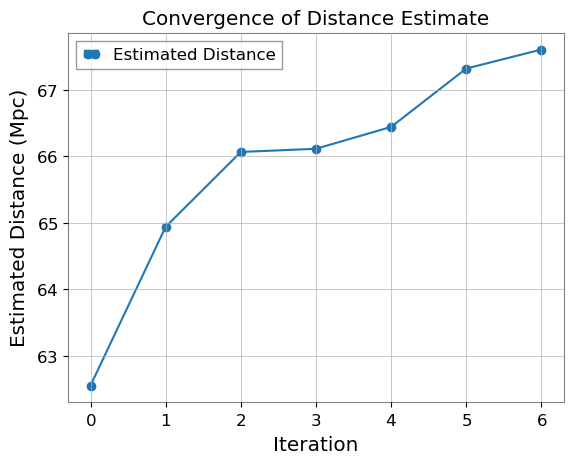

In [29]:
import numpy as np
import h5py
from pycbc.inference import io
from tqdm import tqdm
import matplotlib.pyplot as plt

# Define your initial setup
tolerance = 0.01  # Convergence tolerance for distance in Mpc
max_iterations = 7  # Maximum number of refinement loops
distance_lower = 0   # Lower bound of initial prior
distance_upper = 100  # Upper bound of initial prior
prev_distances = []  # Store distances for each iteration

# Initial run with broad prior
distance_guess = np.random.uniform(distance_lower, distance_upper)
update_prior_config(mass1, mass2, low_freq, approximant, distance_lower, distance_upper, gps)

# Iteratively run inference and update priors
for i in range(max_iterations):
    print(f"Iteration {i+1}, running inference with guess: {distance_guess:.2f} Mpc")
    print('')
    
    # Run PyCBC inference
    !pycbc_inference --config-files model.ini data.ini prior.ini sampler.ini \
        --output-file inference.hdf \
        --nprocesses 16 \
        --force
    
    # Read posterior samples from inference file
    with h5py.File("inference.hdf", "r") as f:
        distance_samples = f["samples"]["distance"][:]
        mean_distance = np.mean(distance_samples)
        lower_bound = np.percentile(distance_samples, 2)
        upper_bound = np.percentile(distance_samples, 98)
        
    # Store mean distance and check convergence
    prev_distances.append(mean_distance)
    if len(prev_distances) > 1 and abs(mean_distance - prev_distances[-2]) < tolerance:
        print(f"Converged to distance: {mean_distance:.2f} Mpc")
        break
    
    # Update bounds based on the new posterior and iterate
    distance_lower = max(0, lower_bound)  # Ensure lower bound is non-negative
    distance_upper = upper_bound
    distance_guess = mean_distance
    update_prior_config(mass1, mass2, low_freq, approximant, distance_lower, distance_upper, gps)

# Plot convergence of distance guesses over iterations
plt.plot(prev_distances, marker='o', label="Estimated Distance")
plt.xlabel("Iteration")
plt.ylabel("Estimated Distance (Mpc)")
plt.title("Convergence of Distance Estimate")
plt.legend()
plt.show()

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import gwpy
from gwpy.signal import filter_design
from scipy.stats import norm
import emcee  # Markov Chain Monte Carlo package
from emcee import EnsembleSampler

# Example data: replace with your actual gravitational wave data
# This should be your observed strain data from LIGO detectors
data = np.random.randn(1000)  # Example random data, replace with actual data
times = np.linspace(0, 1000, 1000)

# Define a simple waveform model, e.g., IMRPhenomD or TaylorF2
def waveform_model(distance, time):
    # This is a placeholder model: replace with actual waveform model
    # This will need to be modified to include the correct model
    return np.sin(2 * np.pi * 100 * time) / distance

# Likelihood function to compare simulated data and real data
def likelihood(distance, data, times):
    # Generate a simulated signal for a given distance
    simulated_data = waveform_model(distance, times)
    
    # Calculate the negative log-likelihood (L2 norm of the residuals)
    residuals = data - simulated_data
    return 0.5 * np.sum(residuals**2)

# Priors for the distance parameter (we assume a Gaussian prior here)
def prior(distance):
    if 1e3 < distance < 1e6:  # Some sensible prior range (1 kpc to 1 Mpc)
        return 0.0  # Flat prior
    else:
        return -np.inf  # Log of zero probability for invalid range

# Log-probability function
def log_probability(params, data, times):
    distance = params[0]
    lp = prior(distance)
    if np.isfinite(lp):
        return -likelihood(distance, data, times) + lp
    else:
        return -np.inf

# Set up MCMC sampling
nwalkers = 50  # Number of walkers
ndim = 1  # Number of dimensions (just distance in this case)
nsteps = 1000  # Number of MCMC steps

# Initial guess for the distance and walkers spread around it
initial_distance = 1e5  # Initial guess (e.g., 100 kpc)
p0 = initial_distance + 1e4 * np.random.randn(nwalkers, ndim)

# Set up MCMC sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(data, times))

# Run MCMC
sampler.run_mcmc(p0, nsteps)

# Analyze the results
samples = EnsembleSampler.get_chain(discard=100, flat=True)  # Burn-in and flatten
distance_samples = samples[:, 0]

# Plot the results
plt.figure(figsize=(10, 6))
plt.hist(distance_samples, bins=50, density=True, label="Posterior distribution")
plt.axvline(np.mean(distance_samples), color="r", linestyle="--", label="Estimated distance")
plt.xlabel('Distance (Mpc)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

# The mean of the posterior distribution gives the best estimate of the distance
estimated_distance = np.mean(distance_samples)
print(f"Estimated distance: {estimated_distance} Mpc")


AttributeError: type object 'EnsembleSampler' has no attribute 'get_chain'

In [40]:
import pycbc.inference
from pycbc.inference import models, likelihood
from pycbc.inference.io import open_inference_file
from pycbc.waveform import get_td_waveform
from pycbc.detector import Detector
import numpy as np

# Load gravitational wave strain data from GWOSC
# Example for GW150914, you would need the GPS time, and specify detectors and data duration
data = load_gw_data('GW150914', detector='H1', gps_start=1126259462, duration=32)

# Define the model for inference, with waveform model and parameters
model = models.Sequential([
    models.CBCGenerator(distance_prior='uniform')  # Use an uninformative prior
])

# Set up the likelihood and prior for the inference
likelihood_model = likelihood.GravitationalWaveTransient(model=model, data=data)

# Run PyCBC inference sampler
result = pycbc.inference.run_sampler(likelihood_model, priors, niterations=10000)

# Extract the posterior samples for distance
distance_samples = result.samples('distance')
mean_distance = np.mean(distance_samples)
distance_uncertainty = np.std(distance_samples)

print(f"Estimated Distance: {mean_distance} ± {distance_uncertainty} Mpc")

ImportError: cannot import name 'likelihood' from 'pycbc.inference' (/home/val/anaconda3/lib/python3.12/site-packages/pycbc/inference/__init__.py)